# Catalogue
1. [Introduction to Data and Pandas Tools] (#1)<br>
2. [Real-time data exploratory analysis](#2)<br>
&emsp;2.1 [Real-time Data Exploratory Analysis of Countries Around the World](#2.1)<br>
&emsp;2.2 [Exploratory analysis of real-time data of all provinces across the country](#2.2)<br>
3. [Exploratory Analysis of Historical Data](#4)<br>
&emsp;3.1 [Exploratory Analysis of National Historical Data](#3.1)<br>
&emsp;3.2 [Exploratory Analysis of Historical Data of Countries around the World](#3.2)<br>
4. [Summary](#4)<br>


# <a id=1></a>1. Introduction to data and Pandas tools

The main content of this project is the exploratory analysis of COVID-19 epidemic data, including real-time data of Chinese provinces and countries around the world, as well as historical data from China and countries around the world. The characteristics and meanings in the data set are shown in the following table:

|List names|Meanings|
|:--|:--|
|date|date|
|name|name|
|id|number|
|lastUpdateTime|Update time|
|today_confirm|New confirmed cases on the same day|
|today_suspect|Newly added on the same day|
|today_heal|New healing on the same day|
|today_dead|New death on the same day|
|today_severe|Added severe illness on the same day|
|today_storeConfirm|Existing confirmed confirmed on the day|
|total_confirm|Cumulative confirmed cases|
|total_suspect|Cumulative suspicion|
|total_heal|Cumulative healing|
|total_dead|Cumulative death|
|total_severe|Cumulative severe illness|


Pandas is an open-source Python library focussing on data analysis. It was originally developed by AQR Capital Management in April 2008 and open sourced at the end of 2009. At present, it continues to be developed and maintained by the PyData development team focussing on the development of Python data packets, which is part of the PyData project. Pandas was originally developed as a financial data analysis tool, so Pandas provides good support for time series analysis.

Pandas is based on NumPy arrays, which can process relational data flexibly and conveniently complete operations such as indexing, slicing, combining and selecting data subsets. Next, let's use Pandas to conduct exploratory analysis of the epidemic data.

# <a id=2></a>2. Real-time data exploratory analysis

## <a id=2.1></a> 2.1 Exploratory analysis of real-time data from all over the world

We first read the data and change the English name of the column to Chinese. Then, check the basic information of the data and process the missing values. In addition, we will add a column of disease and death rates and set the country as an index. After data preprocessing, we will check the top ten countries in the world with the current cumulative number of confirmed cases, and draw horizontal bar charts of cumulative confirmed cases, cumulative deaths and mortality rates to analyse the epidemic situation in each country.

In [1]:
import pandas as pd

# Read the data
today_world = pd.read_csv("./input/today_world_2020_03_31.csv")

In [2]:
# Check the real-time data of countries around the world
today_world.head()

,id,lastUpdateTime,name,total_confirm,total_suspect,total_heal,total_dead,total_severe,today_confirm,today_suspect,today_heal,today_dead,today_severe,today_storeConfirm
0,9577772,2020-03-30 08:29:52,突尼斯,312,0,2,8,0,NaN,0.0,NaN,NaN,0.0,NaN
1,9507896,2020-03-31 13:14:50,塞尔维亚,785,0,0,16,0,44.0,0.0,0.0,3.0,0.0,NaN
2,0,2020-03-31 18:11:03,中国,82599,183,76237,3314,528,151.0,44.0,300.0,3.0,-105.0,NaN
3,1,2020-03-31 10:47:59,日本,2720,0,1027,70,0,19.0,NaN,0.0,0.0,NaN,NaN
4,2,2020-03-31 13:00:41,泰国,1651,0,127,10,0,127.0,0.0,0.0,1.0,0.0,NaN


In [3]:
today_world.tail()

,id,lastUpdateTime,name,total_confirm,total_suspect,total_heal,total_dead,total_severe,today_confirm,today_suspect,today_heal,today_dead,today_severe,today_storeConfirm
193,82333,2020-03-27 11:33:37,格恩西岛,1,0,0,0,0,NaN,0.0,NaN,NaN,0.0,NaN
194,95677,2020-03-31 07:46:01,罗马尼亚,2109,0,209,65,0,349.0,0.0,40.0,23.0,0.0,NaN
195,95436,2020-03-31 17:06:58,阿曼,192,0,34,0,0,13.0,0.0,5.0,0.0,0.0,NaN
196,95672,2020-03-31 00:00:31,列支敦士登,62,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
197,9547021,2020-03-31 08:54:44,马达加斯加,46,0,0,0,0,3.0,0.0,0.0,0.0,0.0,NaN


In [4]:
today_world[:5]

,id,lastUpdateTime,name,total_confirm,total_suspect,total_heal,total_dead,total_severe,today_confirm,today_suspect,today_heal,today_dead,today_severe,today_storeConfirm
0,9577772,2020-03-30 08:29:52,突尼斯,312,0,2,8,0,NaN,0.0,NaN,NaN,0.0,NaN
1,9507896,2020-03-31 13:14:50,塞尔维亚,785,0,0,16,0,44.0,0.0,0.0,3.0,0.0,NaN
2,0,2020-03-31 18:11:03,中国,82599,183,76237,3314,528,151.0,44.0,300.0,3.0,-105.0,NaN
3,1,2020-03-31 10:47:59,日本,2720,0,1027,70,0,19.0,NaN,0.0,0.0,NaN,NaN
4,2,2020-03-31 13:00:41,泰国,1651,0,127,10,0,127.0,0.0,0.0,1.0,0.0,NaN


The names of each column in the data table are in English, which is not easy to observe. We will modify the column names to Chinese. First, create a column name dictionary for Chinese and English comparison, and use the `rename()` function to modify the column name:

In [5]:
name_dict = {'date':'date','name':'name','id':'number','lastUpdateTime':'update time',
'today_confirm': 'new confirmed cases on the same day', 'today_suspect': 'new suspected cases on the same day',
'today_heal': 'new healing on the same day', 'today_dead': 'new death on the same day',
'today_severe': 'new severe cases on the same day', 'today_storeConfirm': 'existing confirmed on the same day',
'total_confirm': 'cumulative confirmed', 'total_suspect': 'cumulative suspicion',
'total_heal':'cumulative cure','total_dead':'cumulative death','total_severe':'cumulative severe illness'}

# Change the column name
# today_world.columns = ['Number','Update time']
today_world.rename(columns=name_dict,inplace=True)    # The inplace parameter determines whether to modify the original data

today_world.head(3)

,number,update time,name,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
0,9577772,2020-03-30 08:29:52,突尼斯,312,0,2,8,0,NaN,0.0,NaN,NaN,0.0,NaN
1,9507896,2020-03-31 13:14:50,塞尔维亚,785,0,0,16,0,44.0,0.0,0.0,3.0,0.0,NaN
2,0,2020-03-31 18:11:03,中国,82599,183,76237,3314,528,151.0,44.0,300.0,3.0,-105.0,NaN


When we get a piece of data, we first need to observe the basic information and statistical information of the characteristics of the data. We can use `info()` to view the basic information of the data:

In [6]:
# Check the basic information of the data
today_world.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   number                               198 non-null    str    
 1   update time                          198 non-null    str    
 2   name                                 198 non-null    str    
 3   cumulative confirmed                 198 non-null    int64  
 4   cumulative suspicion                 198 non-null    int64  
 5   cumulative cure                      198 non-null    int64  
 6   cumulative death                     198 non-null    int64  
 7   cumulative severe illness            198 non-null    int64  
 8   new confirmed cases on the same day  118 non-null    float64
 9   new suspected cases on the same day  161 non-null    float64
 10  new healing on the same day          118 non-null    float64
 11  new death on the same day            118 no

You can use the `describe()` function to view the statistics of the data:

In [7]:
# By default, only statistical information of numerical characteristics is calculated.
today_world.describe()

,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
count,198.000000,198.000000,198.000000,198.000000,198.000000,118.000000,161.000000,118.000000,118.000000,161.000000,0.0
mean,4037.398990,0.924242,849.646465,194.737374,2.666667,469.237288,0.273292,103.466102,23.805085,-0.652174,NaN
std,17471.623547,13.005244,5833.524675,1094.260936,37.523326,2121.255928,3.467686,528.125514,111.088112,8.275159,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-105.000000,NaN
25%,14.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,131.500000,0.000000,3.000000,1.000000,0.000000,45.500000,0.000000,0.500000,1.000000,0.000000,NaN
75%,777.750000,0.000000,38.500000,12.750000,0.000000,140.000000,0.000000,11.750000,4.000000,0.000000,NaN
max,164603.000000,183.000000,76237.000000,11591.000000,528.000000,20349.000000,44.000000,5019.000000,849.000000,0.000000,NaN


In the data, there are a large number of missing values in the new confirmed cases, suspected, cured, death, severe cases and existing confirmed cases on the same day. In order to facilitate observation, we use the `isnull()` function to check the missing value and calculate the ratio of missing values in combination with the `sum()` function.

In [8]:
today_world.isnull().sum()

number                                   0
update time                              0
name                                     0
cumulative confirmed                     0
cumulative suspicion                     0
cumulative cure                          0
cumulative death                         0
cumulative severe illness                0
new confirmed cases on the same day     80
new suspected cases on the same day     37
new healing on the same day             80
new death on the same day               80
new severe cases on the same day        37
existing confirmed on the same day     198
dtype: int64

In [9]:
# Calculate the percentage of missing values
today_world_nan = today_world.isnull().sum()/len(today_world)

# Convert to percentage
today_world_nan.apply(lambda x: format(x, '.1%')) 

number                                   0.0%
update time                              0.0%
name                                     0.0%
cumulative confirmed                     0.0%
cumulative suspicion                     0.0%
cumulative cure                          0.0%
cumulative death                         0.0%
cumulative severe illness                0.0%
new confirmed cases on the same day     40.4%
new suspected cases on the same day     18.7%
new healing on the same day             40.4%
new death on the same day               40.4%
new severe cases on the same day        18.7%
existing confirmed on the same day     100.0%
dtype: str

We found that there were many missing values of the new relevant data on that day, mainly because some countries did not update the data on the day of collecting the data, so we will no longer analyse it. Although all the existing confirmed cases on that day are empty, the missing value can be directly calculated through the existing data. The formula is:

$$ \text{Existing confirmed cases on the same day} = \text{cumulative confirmed cases} - \text{cumulative cures} - \text{cumulative deaths} $$

In [10]:
# Missing value processing

today_world['existing confirmed on the same day'] = today_world['cumulative confirmed']-today_world['cumulative cure']-today_world['cumulative death']

In [11]:
today_world.head()

,number,update time,name,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
0,9577772,2020-03-30 08:29:52,突尼斯,312,0,2,8,0,NaN,0.0,NaN,NaN,0.0,302
1,9507896,2020-03-31 13:14:50,塞尔维亚,785,0,0,16,0,44.0,0.0,0.0,3.0,0.0,769
2,0,2020-03-31 18:11:03,中国,82599,183,76237,3314,528,151.0,44.0,300.0,3.0,-105.0,3048
3,1,2020-03-31 10:47:59,日本,2720,0,1027,70,0,19.0,NaN,0.0,0.0,NaN,1623
4,2,2020-03-31 13:00:41,泰国,1651,0,127,10,0,127.0,0.0,0.0,1.0,0.0,1514


In addition to these characteristics provided in our data, the rate of morbidity is also a very important feature that reflects the severity of the disease and the level of medical care in a region. Next, let's take a look at the disease and death rates in various countries on the day of data collection. The formula for calculating the disease and death rate is:

$$ \text{mortality rate} = \text{cumulative death} \div \text{cumulative confirmed cases} $$

In [12]:
# Calculate the disease and death rate and keep two decimal places.
today_world['mortality'] = (today_world['cumulative death']/today_world['cumulative confirmed']).apply(lambda x: format(x, '.2f'))

# Convert the disease and death rate data type to float
today_world['cumulative death'] = today_world['cumulative death'].astype('float')

In [13]:
today_world.sort_values('cumulative death',ascending=False)

,number,update time,name,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,mortality
157,15,2020-03-31 08:17:43,意大利,101739,0,14620,11591.0,0,4050.0,0.0,1590.0,812.0,0.0,75528,0.11
164,20,2020-03-31 17:39:00,西班牙,94417,0,16780,8189.0,0,9222.0,0.0,2071.0,849.0,0.0,69448,0.09
2,0,2020-03-31 18:11:03,中国,82599,183,76237,3314.0,528,151.0,44.0,300.0,3.0,-105.0,3048,0.04
9,7,2020-03-31 13:53:03,美国,164603,0,5896,3070.0,0,20349.0,0.0,351.0,117.0,0.0,155637,0.02
152,10,2020-03-31 09:35:17,法国,45169,0,7964,3030.0,0,619.0,NaN,0.0,6.0,NaN,34175,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,95879,2020-03-30 00:00:31,梵蒂冈,6,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,6,0.00
193,82333,2020-03-27 11:33:37,格恩西岛,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
195,95436,2020-03-31 17:06:58,阿曼,192,0,34,0.0,0,13.0,0.0,5.0,0.0,0.0,158,0.00
196,95672,2020-03-31 00:00:31,列支敦士登,62,0,0,0.0,0,NaN,NaN,NaN,NaN,NaN,62,0.00


In [14]:
# Sort according to the descending order of the death rate
today_world.sort_values('cumulative death',ascending=False,inplace=True)
# # Showing the top ten countries with disease and death rates
today_world.head(10)

,number,update time,name,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,mortality
157,15,2020-03-31 08:17:43,意大利,101739,0,14620,11591.0,0,4050.0,0.0,1590.0,812.0,0.0,75528,0.11
164,20,2020-03-31 17:39:00,西班牙,94417,0,16780,8189.0,0,9222.0,0.0,2071.0,849.0,0.0,69448,0.09
2,0,2020-03-31 18:11:03,中国,82599,183,76237,3314.0,528,151.0,44.0,300.0,3.0,-105.0,3048,0.04
9,7,2020-03-31 13:53:03,美国,164603,0,5896,3070.0,0,20349.0,0.0,351.0,117.0,0.0,155637,0.02
152,10,2020-03-31 09:35:17,法国,45169,0,7964,3030.0,0,619.0,NaN,0.0,6.0,NaN,34175,0.07
14,826,2020-03-31 17:48:20,伊朗,44606,0,14656,2898.0,0,3111.0,NaN,745.0,141.0,NaN,27052,0.06
156,14,2020-03-31 09:14:43,英国,22453,0,171,1411.0,0,312.0,0.0,20.0,3.0,0.0,20871,0.06
67,95120,2020-03-31 13:10:54,荷兰,11750,0,2500,864.0,0,884.0,0.0,0.0,93.0,0.0,8386,0.07
173,954332,2020-03-31 17:33:14,比利时,12775,0,1696,705.0,0,876.0,0.0,1021.0,192.0,0.0,10374,0.06
8,6,2020-03-31 09:21:46,德国,66885,0,13500,645.0,0,4350.0,0.0,5019.0,212.0,0.0,52740,0.01


排名第一的国家苏丹病死率高达0.29，但从表中可知，该国累计确诊人数只有7例。可见，病死率应结合累计确诊人数一起查看。

为了方便查询特定国家的数据，我们使用`set_index()`函数将国家设置为索引：

In [15]:
# Set the country name as an index
today_world.set_index('name',inplace=True)

today_world.head(3)

,number,update time,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,mortality
name,,,,,,,,,,,,,,
意大利,15,2020-03-31 08:17:43,101739,0,14620,11591.0,0,4050.0,0.0,1590.0,812.0,0.0,75528,0.11
西班牙,20,2020-03-31 17:39:00,94417,0,16780,8189.0,0,9222.0,0.0,2071.0,849.0,0.0,69448,0.09
中国,0,2020-03-31 18:11:03,82599,183,76237,3314.0,528,151.0,44.0,300.0,3.0,-105.0,3048,0.04


In [16]:
today_world.loc['中国']    # Obtain data from multiple countries through the incoming list

number                                                   0
update time                            2020-03-31 18:11:03
cumulative confirmed                                 82599
cumulative suspicion                                   183
cumulative cure                                      76237
cumulative death                                    3314.0
cumulative severe illness                              528
new confirmed cases on the same day                  151.0
new suspected cases on the same day                   44.0
new healing on the same day                          300.0
new death on the same day                              3.0
new severe cases on the same day                    -105.0
existing confirmed on the same day                    3048
mortality                                             0.04
Name: 中国, dtype: object

In [17]:
today_world.sort_values(['cumulative confirmed'],ascending=True)[:10]

,number,update time,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,mortality
name,,,,,,,,,,,,,,
格恩西岛,82333,2020-03-27 11:33:37,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
东帝汶,9523416782,2020-03-22 00:00:31,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
圣文森特和格林纳丁斯,879903,2020-03-27 11:40:20,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
巴布亚新几内亚,95047,2020-03-23 19:41:46,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
格陵兰,95389,2020-03-19 20:28:24,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
圣巴托洛谬岛,95382,2020-03-07 00:00:31,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
萨尔多瓦,84465,2020-03-27 09:23:10,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
波斯尼亚,878,2020-03-06 00:00:31,1,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,1,0.00
圣马丁岛,95287,2020-03-07 00:00:31,2,0,0,0.0,0,NaN,0.0,NaN,NaN,0.0,2,0.00


**Top 10 countries with the current cumulative number of confirmed cases**

Next, let's use the `sort_values()` function to sort according to the cumulative number of confirmed cases, and find the three columns of data on cumulative confirmed cases, cumulative deaths and mortality rates in the top ten countries with confirmed cases:

In [18]:
# Check the top ten countries with the current cumulative number of confirmed cases
world_top10 = today_world.sort_values(['cumulative confirmed'],ascending=False)[:10]

world_top10 = world_top10[['cumulative confirmed', 'cumulative death', 'mortality']]

world_top10

,cumulative confirmed,cumulative death,mortality
name,,,
美国,164603,3070.0,0.02
意大利,101739,11591.0,0.11
西班牙,94417,8189.0,0.09
中国,82599,3314.0,0.04
德国,66885,645.0,0.01
法国,45169,3030.0,0.07
伊朗,44606,2898.0,0.06
英国,22453,1411.0,0.06
瑞士,16176,373.0,0.02


It is not intuitive to observe the data directly. We need to use visualisation methods to analyse it.

In [19]:
# Import matplotlib
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.sans-serif']=['SimHei']    #Normal display of Chinese
plt.rcParams['figure.dpi'] = 120      #Set the clarity of all pictures
matplotlib.rc("font",family='Heiti TC')

Draw a horizontal bar chart of the cumulative confirmed cases, cumulative deaths and mortality rates of the top 10 countries with the current cumulative number of confirmed cases.

In [20]:
world_top10.head()

,cumulative confirmed,cumulative death,mortality
name,,,
美国,164603,3070.0,0.02
意大利,101739,11591.0,0.11
西班牙,94417,8189.0,0.09
中国,82599,3314.0,0.04
德国,66885,645.0,0.01


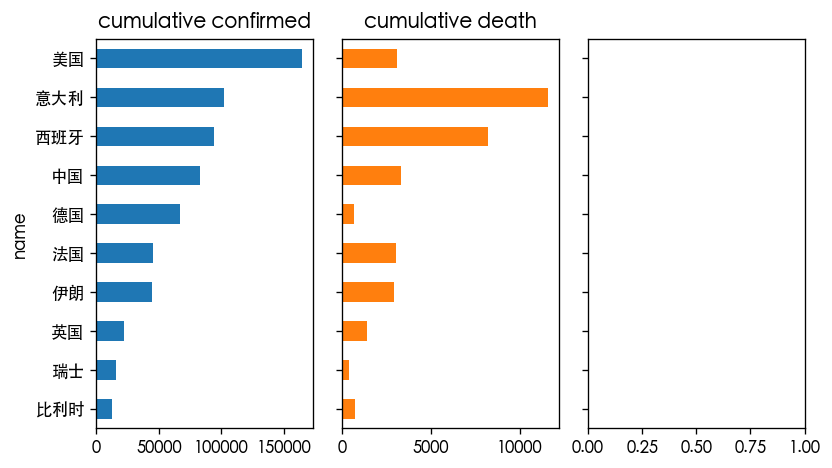

In [21]:
# Draw a bar chart
world_top10.sort_values('cumulative confirmed').plot.barh(subplots=True,layout=(1,3),sharex=False,
                                             figsize=(7,4),legend=False,sharey=True)

plt.tight_layout()   #Adjust the spacing of the sub-picture
plt.show()

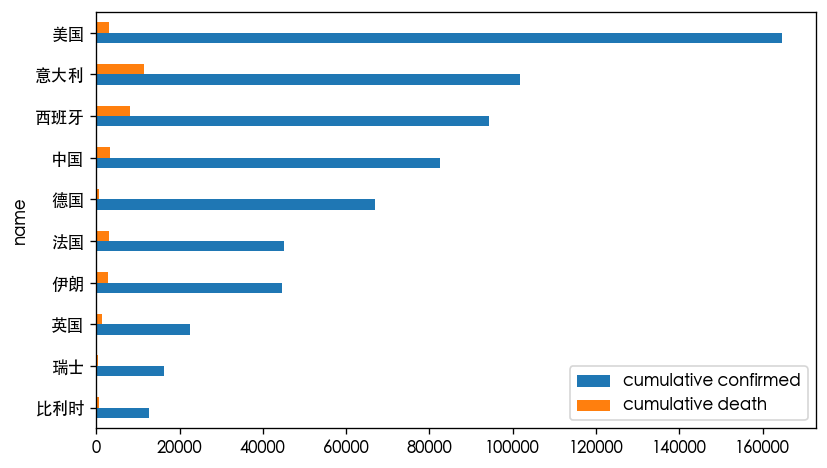

In [22]:
# Draw a bar chart
world_top10.sort_values('cumulative confirmed').plot.barh(figsize=(7,4),legend=True)

plt.tight_layout()   #Adjust the spacing of the sub-picture
plt.show()

It can be seen from the figure that the cumulative number of confirmed cases in the United States is much higher than that of other countries, and the number of confirmed cases in Italy and Spain is also relatively high. Italy ranks first in the chart of the disease and death rate, which shows the severity of the epidemic, followed by the disease and death rates in Spain, France, Iran, the United Kingdom and Belgium. However, the death rate of the United States, which has the highest cumulative number of confirmed cases, is relatively low. One of the reasons is the abundance of medical resources in the United States. The following figure is a national ranking bar chart of the number of ICU beds per 100,000 people:

![](ICU.jpg)

We found that the United States has nearly 35 ICU beds per 100,000 residents, ranking first in the world, followed by Germany with nearly 30 ICU beds. The medical resources of the two countries are much higher than those of other countries, which is also one of the reasons for the relatively low death rate of COVID-19.

## <a id=2.2></a> 2.2 Exploratory analysis of real-time data of all provinces across the country

Next, let's analyse the COVID-19 epidemic situation in China. The pre-processing of real-time data in all provinces across the country is basically the same as the previous process. After data cleaning, we will explore the top 10 new confirmed cases in the country and the top 10 existing confirmed cases in the country respectively.

In [23]:
# Read the data
today_province=pd.read_csv("./input/today_province_2020_03_31.csv")

# Create a Chinese column name dictionary
name_dict = {'date':'date','name':'name','id':'number','lastUpdateTime':'update time',
'today_confirm': 'new confirmed cases on the same day', 'today_suspect': 'new suspected cases on the same day',
'today_heal': 'new healing on the same day', 'today_dead': 'new death on the same day',
'today_severe': 'new severe cases on the same day', 'today_storeConfirm': 'existing confirmed on the same day',
'total_confirm': 'cumulative confirmed', 'total_suspect': 'cumulative suspicion',
'total_heal':'cumulative cure','total_dead':'cumulative death','total_severe':'cumulative severe illness'}

# Change the column name
today_province.rename(columns=name_dict,inplace=True) # Whether the inplace parameter is modified on the basis of the original object
today_province.head()

,number,update time,name,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
0,420000,2020-03-31 08:26:38,湖北,67801,0,63153,3187,0,0,NaN,271,1,NaN,NaN
1,440000,2020-03-31 17:49:10,广东,1494,0,1356,8,0,10,NaN,5,0,NaN,NaN
2,410000,2020-03-31 08:30:02,河南,1276,0,1251,22,0,0,NaN,0,0,NaN,NaN
3,330000,2020-03-31 09:06:29,浙江,1257,0,1226,1,0,2,NaN,1,0,NaN,NaN
4,430000,2020-03-31 08:27:03,湖南,1018,0,1014,4,0,0,NaN,0,0,NaN,NaN


In [24]:
# Check the basic information of the data
today_province.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   number                               34 non-null     int64  
 1   update time                          34 non-null     str    
 2   name                                 34 non-null     str    
 3   cumulative confirmed                 34 non-null     int64  
 4   cumulative suspicion                 34 non-null     int64  
 5   cumulative cure                      34 non-null     int64  
 6   cumulative death                     34 non-null     int64  
 7   cumulative severe illness            34 non-null     int64  
 8   new confirmed cases on the same day  34 non-null     int64  
 9   new suspected cases on the same day  3 non-null      float64
 10  new healing on the same day          34 non-null     int64  
 11  new death on the same day            34 non-n

Use `describe()` to view the statistical information of the data:

In [25]:
# View the statistics of numerical characteristics
today_province.describe()

,number,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
count,34.000000,34.000000,34.0,34.000000,34.000000,34.0,34.000000,3.0,34.000000,34.000000,3.0,0.0
mean,422941.176471,2429.382353,0.0,2242.264706,97.470588,0.0,4.441176,0.0,8.823529,0.088235,0.0,NaN
std,195021.823359,11557.886325,0.0,10769.927341,545.923418,0.0,13.089879,0.0,46.386042,0.378806,0.0,NaN
min,110000.000000,1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,NaN
25%,312500.000000,138.250000,0.0,124.250000,1.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,NaN
50%,425000.000000,321.500000,0.0,246.000000,3.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,NaN
75%,537500.000000,697.000000,0.0,615.750000,6.000000,0.0,2.750000,0.0,0.000000,0.000000,0.0,NaN
max,820000.000000,67801.000000,0.0,63153.000000,3187.000000,0.0,73.000000,0.0,271.000000,2.000000,0.0,NaN


We found that the cumulative data of suspected cases, cumulative severe cases, new suspected cases on the same day and new severe cases on the day were all 0, so we did not consider them.

In [26]:
# Calculate the number of confirmed cases in each province on the same day

today_province['existing confirmed on the same day'] = today_province['cumulative confirmed']-today_province['cumulative cure']-today_province['cumulative death']

# Set the provincial name as an index

today_province.set_index('name',inplace=True)

today_province.info()

<class 'pandas.DataFrame'>
Index: 34 entries, 湖北 to 西藏
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   number                               34 non-null     int64  
 1   update time                          34 non-null     str    
 2   cumulative confirmed                 34 non-null     int64  
 3   cumulative suspicion                 34 non-null     int64  
 4   cumulative cure                      34 non-null     int64  
 5   cumulative death                     34 non-null     int64  
 6   cumulative severe illness            34 non-null     int64  
 7   new confirmed cases on the same day  34 non-null     int64  
 8   new suspected cases on the same day  3 non-null      float64
 9   new healing on the same day          34 non-null     int64  
 10  new death on the same day            34 non-null     int64  
 11  new severe cases on the same day     3 non-null  

**Top 10 new confirmed cases in the country**

At present, the epidemic in China has been well controlled, and we are now paying more attention to the areas with new confirmed cases.

In [27]:
# Check the top 10 new confirmed cases in the country
new_top6 = today_province['new confirmed cases on the same day'].sort_values(ascending=False)[:10]

new_top6

name
香港     73
台湾     24
上海     11
广东     10
内蒙古    10
天津      8
北京      3
辽宁      3
福建      3
浙江      2
Name: new confirmed cases on the same day, dtype: int64

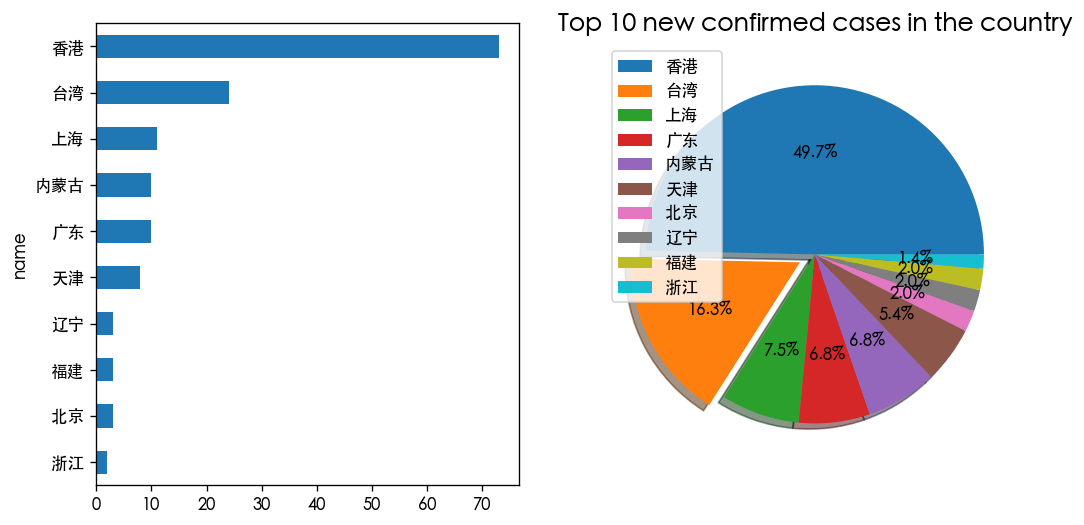

In [28]:
# Draw bar charts and pie charts
fig,ax = plt.subplots(1,2,figsize=(10,5))

new_top6.sort_values(ascending=True).plot.barh(fontsize=10,ax=ax[0])
explode = (0,0.1,0,0,0,0,0,0,0,0)
new_top6.plot.pie(explode=explode,shadow=True,labels=None,\
                  legend=True,autopct='%.1f%%',fontsize=10,ax=ax[1])

plt.ylabel('')
plt.title('Top 10 new confirmed cases in the country',size=15)
plt.show()

It can be seen from the figure that Hong Kong and Taiwan have the largest number of new confirmed cases, and Hong Kong accounts for nearly half of the top ten new confirmed cases.

**Top 10 areas with the number of confirmed cases in the country**

Next, let's check the top ten existing confirmed cases in the country.

In [29]:
# Check the top 10 provinces and cities with existing confirmed cases in the country

store_top10 = today_province['existing confirmed on the same day'].sort_values(ascending=False)[:10]

store_top10

name
湖北     1461
香港      582
台湾      278
上海      163
北京      154
广东      130
福建       47
天津       38
内蒙古      32
浙江       30
Name: existing confirmed on the same day, dtype: int64

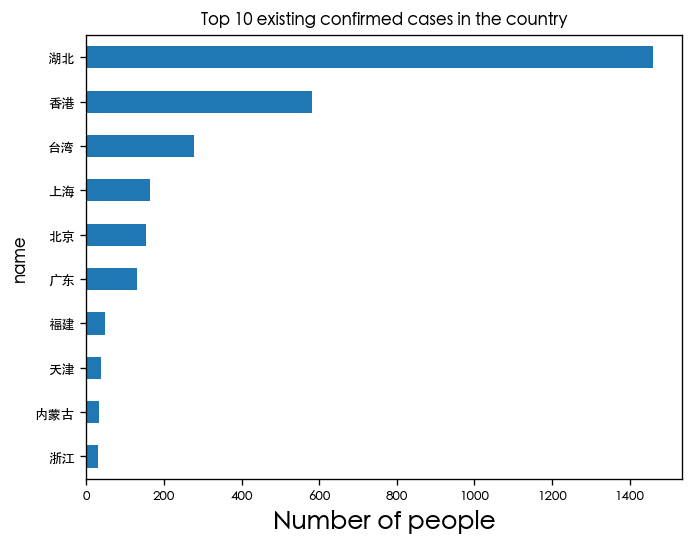

In [30]:
# Draw a bar chart

store_top10.sort_values(ascending=True).plot.barh(fontsize=8)

plt.title('Top 10 existing confirmed cases in the country',size=10)
plt.xlabel('Number of people', size=15)
plt.show()

Although the number of confirmed cases in Hubei still ranks first, there are relatively few new confirmed cases.

# <a id=3></a>3. Exploratory analysis of historical data

## <a id=3.1></a> 3.1 Exploratory analysis of national historical data

National historical data is a data type of time series, and time needs to be processed during data cleaning. At the end of this part, we will draw a line chart of the national historical data and focus on analysing the trend of the number of new confirmed cases in the country.

In [31]:
# Read the data
alltime_china = pd.read_csv("./input/alltime_China_2020_03_31.csv")

# Create a Chinese column name dictionary
name_dict = {'date':'date','name':'name','id':'number','lastUpdateTime':'update time',
'today_confirm': 'new confirmed cases on the same day', 'today_suspect': 'new suspected cases on the same day',
'today_heal': 'new healing on the same day', 'today_dead': 'new death on the same day',
'today_severe': 'new severe cases on the same day', 'today_storeConfirm': 'existing confirmed on the same day',
'total_confirm': 'cumulative confirmed', 'total_suspect': 'cumulative suspicion',
'total_heal':'cumulative cure','total_dead':'cumulative death','total_severe':'cumulative severe illness'}

# Change the column name

alltime_china.rename(columns=name_dict,inplace=True)
alltime_china.head()

,date,update time,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
0,2020-01-20,NaN,291,54,25,6,0,291,27,25,6,0,NaN
1,2020-01-21,NaN,440,37,25,9,102,149,26,0,3,0,NaN
2,2020-01-22,NaN,571,393,28,17,95,131,257,3,8,0,NaN
3,2020-01-23,NaN,830,1072,34,25,177,259,680,6,8,0,NaN
4,2020-01-24,NaN,1287,1965,38,41,237,457,1118,4,16,0,NaN


In [32]:
alltime_china.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   date                                 71 non-null     str    
 1   update time                          0 non-null      float64
 2   cumulative confirmed                 71 non-null     int64  
 3   cumulative suspicion                 71 non-null     int64  
 4   cumulative cure                      71 non-null     int64  
 5   cumulative death                     71 non-null     int64  
 6   cumulative severe illness            71 non-null     int64  
 7   new confirmed cases on the same day  71 non-null     int64  
 8   new suspected cases on the same day  71 non-null     int64  
 9   new healing on the same day          71 non-null     int64  
 10  new death on the same day            71 non-null     int64  
 11  new severe cases on the same day     71 non-n

In [33]:
# Check the statistics of the data
alltime_china.describe()

,update time,cumulative confirmed,cumulative suspicion,cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
count,0.0,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.0,0.0
mean,NaN,58272.267606,6094.830986,33245.281690,2025.056338,4796.183099,1148.140845,1378.154930,1071.154930,46.549296,0.0,NaN
std,NaN,30572.980946,8497.722887,29864.644742,1264.722329,3724.337603,1985.171351,1749.404925,930.775616,43.866612,0.0,NaN
min,NaN,291.000000,37.000000,25.000000,6.000000,0.000000,11.000000,17.000000,0.000000,1.000000,0.0,NaN
25%,NaN,32853.500000,178.500000,1795.000000,679.000000,1550.000000,46.500000,42.500000,302.000000,9.500000,0.0,NaN
50%,NaN,77658.000000,1418.000000,27323.000000,2663.000000,4020.000000,397.000000,439.000000,819.000000,30.000000,0.0,NaN
75%,NaN,80818.500000,8598.500000,64826.000000,3182.500000,7514.500000,1934.500000,2363.500000,1679.500000,73.000000,0.0,NaN
max,NaN,81518.000000,28942.000000,76052.000000,3305.000000,11977.000000,14108.000000,5328.000000,3622.000000,150.000000,0.0,NaN


In [34]:
# Missing value processing
# Calculate the number of existing confirmed cases on that day
alltime_china['existing confirmed cases on the same day'] = alltime_china['cumulative confirmed']-alltime_china['cumulative cure']-alltime_china['cumulative death']

# Delete the update time column
alltime_china.drop(['update time','new severe cases on the same day'],axis=1,inplace=True)
alltime_china.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   date                                      71 non-null     str    
 1   cumulative confirmed                      71 non-null     int64  
 2   cumulative suspicion                      71 non-null     int64  
 3   cumulative cure                           71 non-null     int64  
 4   cumulative death                          71 non-null     int64  
 5   cumulative severe illness                 71 non-null     int64  
 6   new confirmed cases on the same day       71 non-null     int64  
 7   new suspected cases on the same day       71 non-null     int64  
 8   new healing on the same day               71 non-null     int64  
 9   new death on the same day                 71 non-null     int64  
 10  existing confirmed on the same day        0 non-nul

In [35]:
alltime_china = alltime_china.reset_index()

Compared with real-time data, the date column of historical data is very important. We use `pd.to_datetime()` to set the data type of the date to `datetime` and set it to the row index.

In [36]:
alltime_china.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 13 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   index                                     71 non-null     int64  
 1   date                                      71 non-null     str    
 2   cumulative confirmed                      71 non-null     int64  
 3   cumulative suspicion                      71 non-null     int64  
 4   cumulative cure                           71 non-null     int64  
 5   cumulative death                          71 non-null     int64  
 6   cumulative severe illness                 71 non-null     int64  
 7   new confirmed cases on the same day       71 non-null     int64  
 8   new suspected cases on the same day       71 non-null     int64  
 9   new healing on the same day               71 non-null     int64  
 10  new death on the same day                 71 non-nu

In [37]:
# Change the date to datetime format
# alltime_china['date'] = pd.to_datetime(alltime_china['date'])
# Set the date as the index

alltime_china.set_index('date',inplace=True)     # You can also use pd.read_csv("./input/alltime_China_2020_03_27.csv",parse_dates=['date'],index_col='date')

alltime_china.index

Index(['2020-01-20', '2020-01-21', '2020-01-22', '2020-01-23', '2020-01-24',
       '2020-01-25', '2020-01-26', '2020-01-27', '2020-01-28', '2020-01-29',
       '2020-01-30', '2020-01-31', '2020-02-01', '2020-02-02', '2020-02-03',
       '2020-02-04', '2020-02-05', '2020-02-06', '2020-02-07', '2020-02-08',
       '2020-02-09', '2020-02-10', '2020-02-11', '2020-02-12', '2020-02-13',
       '2020-02-14', '2020-02-15', '2020-02-16', '2020-02-17', '2020-02-18',
       '2020-02-19', '2020-02-20', '2020-02-21', '2020-02-22', '2020-02-23',
       '2020-02-24', '2020-02-25', '2020-02-26', '2020-02-27', '2020-02-28',
       '2020-02-29', '2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
       '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08', '2020-03-09',
       '2020-03-10', '2020-03-11', '2020-03-12', '2020-03-13', '2020-03-14',
       '2020-03-15', '2020-03-16', '2020-03-17', '2020-03-18', '2020-03-19',
       '2020-03-20', '2020-03-21', '2020-03-22', '2020-03-23', '2020-03-24',

After setting the period index, the selection of data will be very convenient.

After data cleaning, we will draw a line chart to check the changing trend of COVID-19 data:

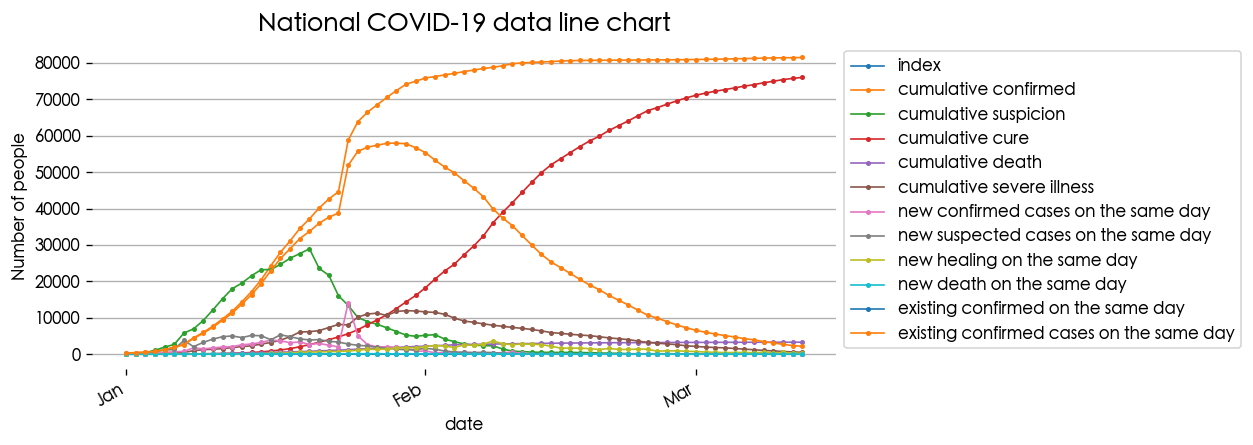

In [38]:
# Time series data drawing line diagram
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import matplotlib.ticker as ticker
import datetime

fig, ax = plt.subplots(figsize=(8,4))

alltime_china.plot(marker='o',ms=2,lw=1,ax=ax)

ax.xaxis.set_major_locator(dates.MonthLocator())    #Set the spacing
ax.xaxis.set_major_formatter(dates.DateFormatter('%b'))    #Set the date format

fig.autofmt_xdate()    #Automatically adjust the date tilt

# The position of the legend is adjusted
plt.legend(bbox_to_anchor = [1,1])

plt.title('National COVID-19 data line chart',size=15)
plt.ylabel('Number of people')
plt.grid(axis='y')
plt.box(False)
plt.show()

It can be seen from the figure that the cumulative number of confirmed cases in China has reached an inflection point in mid-February, and the number of existing confirmed cases has gradually decreased since February 15. At the same time, the cumulative number of cured people has risen steadily, and with the decline in the number of existing confirmed cases, it has gradually calmed down. Since the field values such as new confirmed cases are relatively small, we will analyse them separately.

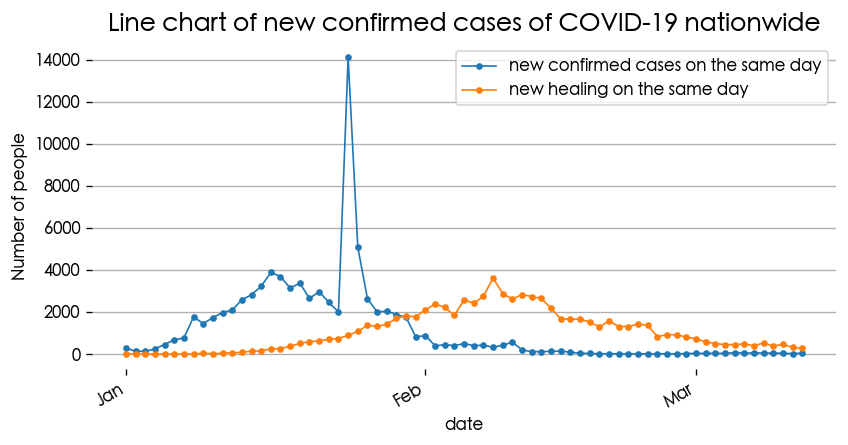

In [39]:
from matplotlib import dates

# Time series data drawing line diagram
fig, ax = plt.subplots(figsize=(8, 4))

alltime_china[['new confirmed cases on the same day', 'new healing on the same day']].plot(
    ax=ax, style='-', lw=1, marker='o', ms=3)  # ax=ax, not axe=axe

ax.xaxis.set_major_locator(dates.MonthLocator())
ax.xaxis.set_major_formatter(dates.DateFormatter('%b'))
fig.autofmt_xdate()  

plt.title('Line chart of new confirmed cases of COVID-19 nationwide', size=15)
plt.ylabel('Number of people')
plt.grid(axis='y')   
plt.box(False)       
plt.show()

It can be seen that the number of new cases has increased sharply on February 12. What is the reason for this? If you are very concerned about the epidemic, you should know that this is because the National Health Commission adjusted the criteria for confirmed cases on that day. Previously, the main reference indicator for whether the patient was diagnosed was the nucleic acid test result, and it also needed to be judged comprehensively in combination with CT images, coughing and other symptoms. With the deepening of epidemic prevention and control and the continuous accumulation of clinical data, a new situation has gradually emerged - due to the slow time of nucleic acid testing, some patients cannot be diagnosed and admitted, but the clinical manifestations of the symptoms are highly suspected of COVID-19. If the identification criteria are not changed, it will be difficult for these patients to get effective assistance, which will also have a negative impact on the whole epidemic prevention and control. The main change this time is to include clinical diagnosis in the scope of diagnosis.

## <a id=3.2></a> 3.2 Exploratory analysis of historical data of countries around the world

Finally, let's analyse the historical data of countries around the world. Since each country in the data table contains multiple data, we need to group the data with the help of GroupBy technology, and select the cumulative confirmed and new confirmed data of multiple countries through hierarchical indexing to check the trend of epidemic changes in various countries.

In [40]:
# Read the data
alltime_world = pd.read_csv("./input/alltime_world_2020_03_31.csv")

# Create a Chinese column name dictionary
name_dict = {'date':'date','name':'name','id':'number','lastUpdateTime':'update time',
'today_confirm': 'new confirmed cases on the same day', 'today_suspect': 'new suspected cases on the same day',
'today_heal': 'new healing on the same day', 'today_dead': 'new death on the same day',
'today_severe': 'new severe cases on the same day', 'today_storeConfirm': 'existing confirmed on the same day',
'total_confirm': 'cumulative confirmed', 'total_suspect': 'cumulative suspicion',
'total_heal':'Cumulative cure','total_dead':'cumulative death','total_severe':'cumulative severe illness'}

# Change the column name
alltime_world.rename(columns=name_dict,inplace=True)
alltime_world.head()

,date,cumulative confirmed,cumulative suspicion,Cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,name
0,2020-03-03,1,0,0,0,0,1,0.0,0,0,NaN,NaN,突尼斯
1,2020-03-08,2,0,0,0,0,1,0.0,0,0,0.0,NaN,突尼斯
2,2020-03-09,5,0,0,0,0,3,0.0,0,0,0.0,NaN,突尼斯
3,2020-03-11,7,0,0,0,0,2,0.0,0,0,0.0,NaN,突尼斯
4,2020-03-12,13,0,0,0,0,6,0.0,0,0,0.0,NaN,突尼斯


In [41]:
# Check the basic information of the data
alltime_world.info()

<class 'pandas.DataFrame'>
RangeIndex: 3048 entries, 0 to 3047
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   date                                 3048 non-null   str    
 1   cumulative confirmed                 3048 non-null   int64  
 2   cumulative suspicion                 3048 non-null   int64  
 3   Cumulative cure                      3048 non-null   int64  
 4   cumulative death                     3048 non-null   int64  
 5   cumulative severe illness            3048 non-null   int64  
 6   new confirmed cases on the same day  3048 non-null   int64  
 7   new suspected cases on the same day  2912 non-null   float64
 8   new healing on the same day          3048 non-null   int64  
 9   new death on the same day            3048 non-null   int64  
 10  new severe cases on the same day     2512 non-null   float64
 11  existing confirmed on the same day   0 no

In [42]:
alltime_world.describe()

,cumulative confirmed,cumulative suspicion,Cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day
count,3048.000000,3048.000000,3048.000000,3048.000000,3048.000000,3048.000000,2912.000000,3048.000000,3048.000000,2512.000000,0.0
mean,3275.215879,89.309055,1006.174541,132.135499,35.017388,262.135499,15.595467,55.206693,12.646982,-2.882564,NaN
std,13482.084538,1253.684029,6980.113868,698.118983,403.228076,1290.621505,201.004634,306.368872,73.263761,27.524887,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-464.000000,NaN
25%,16.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,90.000000,0.000000,1.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,554.500000,0.000000,16.000000,6.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,NaN
max,164603.000000,28942.000000,76237.000000,11591.000000,7365.000000,26154.000000,4008.000000,5352.000000,1386.000000,0.000000,NaN


The data preprocessing operation is basically the same as the previous method:

In [43]:
# Change the date column data type to datetime
alltime_world['date'] = pd.to_datetime(alltime_world['date'])

# Calculate the current confirmed cases on the same day
alltime_world['existing confirmed cases on the same day'] = alltime_world['cumulative confirmed']-alltime_world['Cumulative cure']-alltime_world['cumulative death']
alltime_world.info()

<class 'pandas.DataFrame'>
RangeIndex: 3048 entries, 0 to 3047
Data columns (total 14 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   date                                      3048 non-null   datetime64[us]
 1   cumulative confirmed                      3048 non-null   int64         
 2   cumulative suspicion                      3048 non-null   int64         
 3   Cumulative cure                           3048 non-null   int64         
 4   cumulative death                          3048 non-null   int64         
 5   cumulative severe illness                 3048 non-null   int64         
 6   new confirmed cases on the same day       3048 non-null   int64         
 7   new suspected cases on the same day       2912 non-null   float64       
 8   new healing on the same day               3048 non-null   int64         
 9   new death on the same day                

What are the total number of countries in the data table? We can use `unique()` to view the unique value in the data:

In [44]:
alltime_world['name'].nunique()

198

In [45]:
# To view the unique value, you can use len() to view the number.
alltime_world['name'].unique()

<StringArray>
[  '突尼斯',  '塞尔维亚',    '中国',    '日本',    '泰国',   '新加坡',    '韩国',  '澳大利亚',
    '德国',    '美国',
 ...
 '哈萨克斯坦',   '安道尔',   '牙买加',  '格恩西岛',  '罗马尼亚',    '阿曼', '列支敦士登', '马达加斯加',
  '法罗群岛', '马提尼克岛']
Length: 198, dtype: str

At the same time, we also want to know how many countries have the COVID-19 epidemic every day. The `value_counts()` function can help us see how much data is recorded every day.

In [46]:
# Count how many countries have epidemics every day.
alltime_world['date'].value_counts().head(20)

date
2020-03-26    157
2020-03-27    130
2020-03-22    129
2020-03-25    125
2020-03-28    120
2020-03-24    118
2020-03-23    116
2020-03-14    113
2020-03-29    110
2020-03-19    109
2020-03-20    106
2020-03-13    105
2020-03-15    102
2020-03-30     97
2020-03-21     96
2020-03-16     94
2020-03-18     94
2020-03-17     86
2020-03-10     73
2020-03-11     71
Name: count, dtype: int64

According to the data, the number of countries with the epidemic on March 26 has reached 157.

In [47]:
# Sort the index first
alltime_world.sort_index(inplace=True)

# Now slice works correctly
alltime_world = alltime_world.loc[:'2020-03-31']

**Choose multi-country data**

Next, we would like to extract data from China, Japan, South Korea, the United States, Italy, the United Kingdom, Spain and Germany to explore the trend of cumulative confirmed and new confirmed cases in these eight countries. We will use GroupBy technology and hierarchical indexing operation. GroupBy technology is a technique for grouping data and combining the calculation results of each group, including the following three processes:

<img src='http://cookdata.cn/media/note_images/groupby技术_1585496694168_5d14.jpg' style='max-width:40%;'>

If you want to extract data from multiple countries, you need to index the country column. We can use the `groupby()` function to group the two columns according to the date and name to convert the data into a hierarchical index.

In [48]:
# groupby creates a hierarchical index
data = alltime_world.groupby(['date','name']).mean()

data.head()

,,cumulative confirmed,cumulative suspicion,Cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,existing confirmed cases on the same day
date,name,,,,,,,,,,,,
2020-01-20,韩国,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,1.0
2020-01-21,韩国,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0
2020-01-22,韩国,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0
2020-01-23,韩国,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0
2020-01-24,韩国,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,2.0


If you want to extract some data, you can also use the `.loc` method. You need to specify whether to index the row or the column index through `.loc(axis= )` first. For example, we want to extract data from China, South Korea, the United States, Italy, the United Kingdom, Spain and Germany:

In [49]:
print(data.index.get_level_values('name').unique().tolist())

['韩国', '日本', '中国', '德国', '新加坡', '泰国', '澳大利亚', '美国', '越南', '马来西亚', '伊朗', '以色列', '黎巴嫩', '阿富汗', '巴林', '科威特', '克罗地亚', '奥地利', '巴西', '瑞士', '巴基斯坦', '希腊', '丹麦', '北马其顿', '尼日利亚', '爱沙尼亚', '荷兰', '摩纳哥', '新西兰', '白俄罗斯', '立陶宛', '阿塞拜疆', '厄瓜多尔', '爱尔兰', '卢森堡', '埃及', '捷克', '塞内加尔', '摩洛哥', '乌克兰', '智利', '沙特阿拉伯', '突尼斯', '阿根廷', '匈牙利', '斯洛文尼亚', '波兰', '南非', '巴勒斯坦', '波斯尼亚', '波黑', '哥斯达黎加', '喀麦隆', '圣巴托洛谬岛', '斯洛伐克', '直布罗陀', '秘鲁', '多哥共和国', '摩尔多瓦', '马尔代夫', '马耳他', '保加利亚', '孟加拉国', '巴拉圭', '法属圭亚那', '塞尔维亚', '塞浦路斯', '巴拿马', '文莱', '蒙古', '阿尔巴尼亚', '古巴', '圭亚那', '洪都拉斯', '刚果（金）', '法属波利尼西亚', '乌拉圭', '几内亚', '加纳', '危地马拉', '委内瑞拉', '毛里塔尼亚', '法属留尼汪岛', '肯尼亚', '苏里南', '中非共和国', '刚果（布）', '卢旺达', '斯威士兰', '波多黎各', '科索沃', '纳米比亚', '赤道几内亚', '乌兹别克斯坦', '巴哈马', '利比里亚', '坦桑尼亚', '格陵兰', '索马里', '贝宁', '冈比亚', '巴巴多斯', '黑山', '吉尔吉斯斯坦', '毛里求斯', '萨尔瓦多', '赞比亚', '乍得', '佛得角', '尼加拉瓜', '尼日尔', '斐济', '萨尔多瓦', '津巴布韦', '东帝汶', '乌干达', '厄立特里亚', '叙利亚', '多米尼克', '莫桑比克', '伯利兹', '缅甸', '老挝', '马里', '关岛', '圣巴泰勒米', '格林纳达', '泽西岛', '美属维尔京群岛', '荷属安的列斯', '蒙特塞拉特', '阿鲁巴', '马约特岛', '博茨瓦纳']


In [50]:
# Extract some data
data_part = data.loc(axis=0)[:,['中国','日本','韩国','美国','意大利','英国','西班牙','德国']]

data_part.tail()

KeyError: '意大利'

At this time, the multi-level index has been set successfully. If we want to return it, we can use the `reset_index()` function.

In [86]:
# Restore the hierarchical index
data_part.reset_index('name',inplace=True)

data_part.head()

,name,cumulative confirmed,cumulative suspicion,Cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,existing confirmed cases on the same day
date,,,,,,,,,,,,,
2020-02-05,中国,24433.0,23260.0,962.0,493.0,0.0,24433.0,3971.0,962.0,493.0,NaN,NaN,22978.0
2020-02-06,中国,31161.0,26359.0,1540.0,637.0,0.0,6728.0,3230.0,578.0,144.0,NaN,NaN,28984.0
2020-02-07,中国,34598.0,27657.0,2052.0,723.0,0.0,3437.0,0.0,512.0,86.0,NaN,NaN,31823.0
2020-02-08,中国,37162.0,28942.0,2651.0,812.0,0.0,2564.0,3916.0,599.0,89.0,NaN,NaN,33699.0
2020-02-09,中国,40224.0,23589.0,3282.0,909.0,0.0,3062.0,4008.0,631.0,97.0,NaN,NaN,36033.0


**Draw a line chart of the cumulative number of confirmed cases in multiple countries**

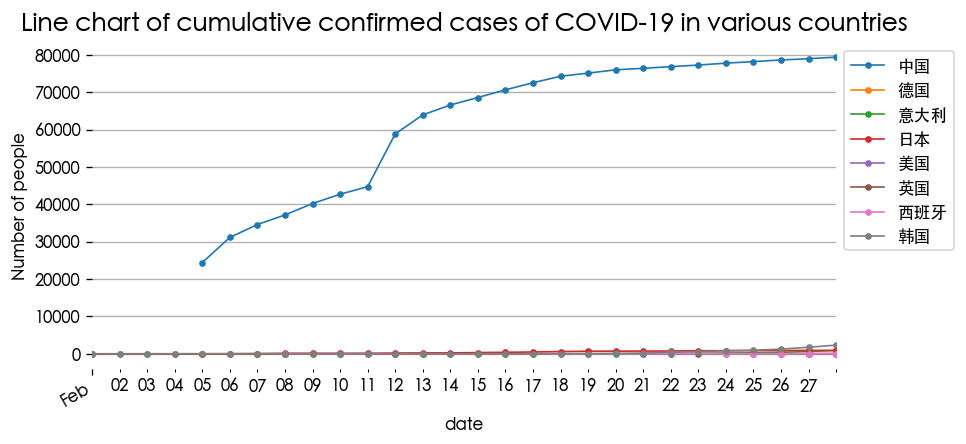

In [89]:
# Draw a line chart of the cumulative number of confirmed cases in multiple countries
data_part.sort_index(inplace=True)  # add this

fig, ax = plt.subplots(figsize=(8, 4))
data_part.loc['2020-02':'2020-02-28'].groupby('name')['cumulative confirmed'].plot(
    legend=True, marker='o', ms=3, lw=1)
ax.xaxis.set_major_locator(dates.MonthLocator())
ax.xaxis.set_major_formatter(dates.DateFormatter('%b'))
fig.autofmt_xdate()
plt.title('Line chart of cumulative confirmed cases of COVID-19 in various countries', size=15)
plt.ylabel('Number of people')
plt.grid(axis='y')
plt.box(False)
plt.legend(bbox_to_anchor=[1, 1])
plt.show()

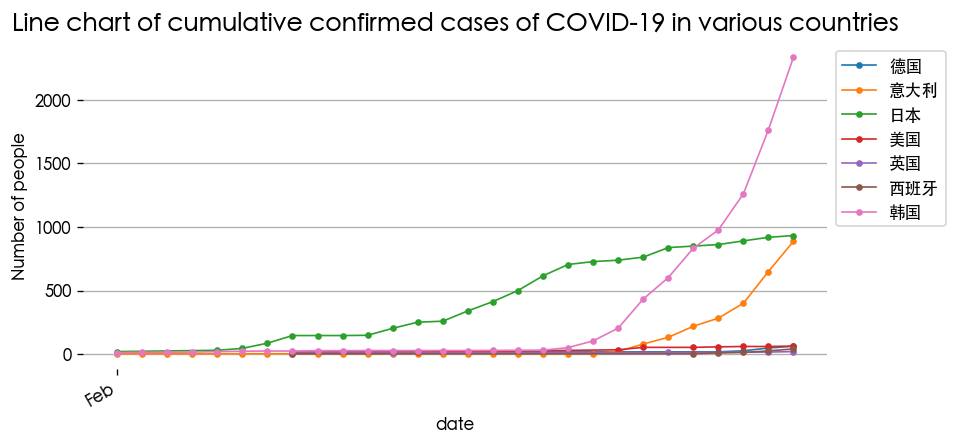

In [92]:
# Draw a line chart of the cumulative number of confirmed cases in multiple countries
fig, ax = plt.subplots(figsize=(8,4))

data_part[data_part['name']!='中国'].loc['2020-02':'2020-02-28'].groupby('name')['cumulative confirmed'].plot(legend=True,marker='o',ms=3,lw=1)

ax.xaxis.set_major_locator(dates.MonthLocator())    #Set the spacing
ax.xaxis.set_major_formatter(dates.DateFormatter('%b'))    #Set the date format

fig.autofmt_xdate()    #Automatically adjust the date tilt

plt.title('Line chart of cumulative confirmed cases of COVID-19 in various countries',size=15)
plt.ylabel('Number of people')
plt.grid(axis='y')
plt.box(False)
plt.legend(bbox_to_anchor = [1,1])
plt.show()

Finally, let's observe the changes in the number of new confirmed cases in various countries. Here we only check the latest data of March.

The number of new confirmed cases in various countries fluctuates greatly, but the overall trend is on the rise. In late March, the number of new cases in a single day in the United States and Spain exceeded 10,000 for the first time, and the latest data shows that the number of new cases in the United States has exceeded 25,000 in a single day.

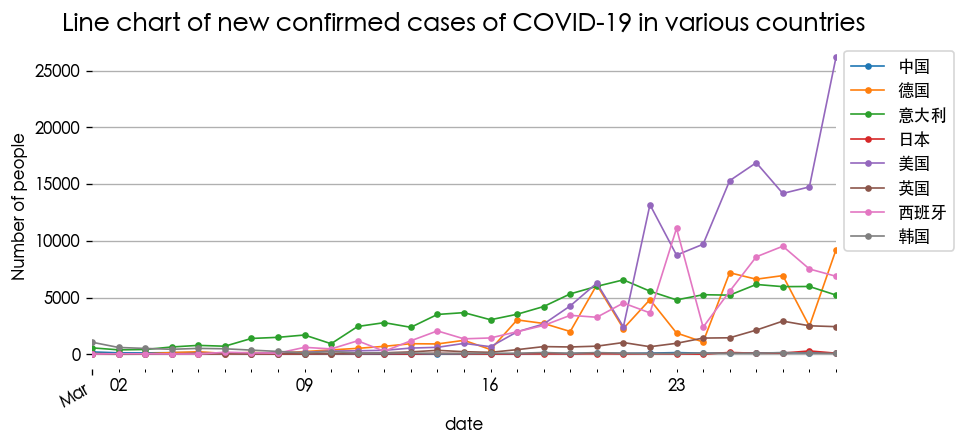

In [97]:
# Draw a line chart of the number of new confirmed cases in each country
fig, ax = plt.subplots(figsize=(8,4))

data_part.loc['2020-03':'2020-03-29'].groupby('name')['new confirmed cases on the same day'].plot(legend=True,marker='o',ms=3,lw=1)

ax.xaxis.set_major_locator(dates.MonthLocator())    #Set the spacing
ax.xaxis.set_major_formatter(dates.DateFormatter('%b'))    #Set the date format

fig.autofmt_xdate()    #Automatically adjust the date tilt

plt.title('Line chart of new confirmed cases of COVID-19 in various countries',size=15)
plt.ylabel('Number of people')
plt.grid(axis='y')
plt.box(False)
plt.legend(bbox_to_anchor = [1,1])
plt.show()

In the previous two pictures, we found that it is difficult to observe the changing trend of the epidemic in Japan due to the small data. Here we separately selected two columns of data on the cumulative confirmed cases of COVID-19 in Japan and the new confirmed cases on the same day:

In [98]:
alltime_world[alltime_world['name']=='日本']

,cumulative confirmed,cumulative suspicion,Cumulative cure,cumulative death,cumulative severe illness,new confirmed cases on the same day,new suspected cases on the same day,new healing on the same day,new death on the same day,new severe cases on the same day,existing confirmed on the same day,name,existing confirmed cases on the same day
date,,,,,,,,,,,,,
2020-01-28,4,0,0,0,0,4,0.0,0,0,NaN,NaN,日本,4
2020-01-30,6,0,0,0,0,2,0.0,0,0,NaN,NaN,日本,6
2020-01-31,15,0,0,0,0,9,0.0,0,0,NaN,NaN,日本,15
2020-02-01,20,0,0,0,0,5,0.0,0,0,NaN,NaN,日本,20
2020-02-05,30,0,0,0,0,10,0.0,0,0,NaN,NaN,日本,30
2020-02-06,45,0,0,0,0,15,0.0,0,0,NaN,NaN,日本,45
2020-02-07,86,0,0,0,0,41,0.0,0,0,NaN,NaN,日本,86
2020-02-08,146,0,1,0,0,60,0.0,1,0,NaN,NaN,日本,145
2020-02-09,146,0,1,0,0,0,0.0,0,0,NaN,NaN,日本,145


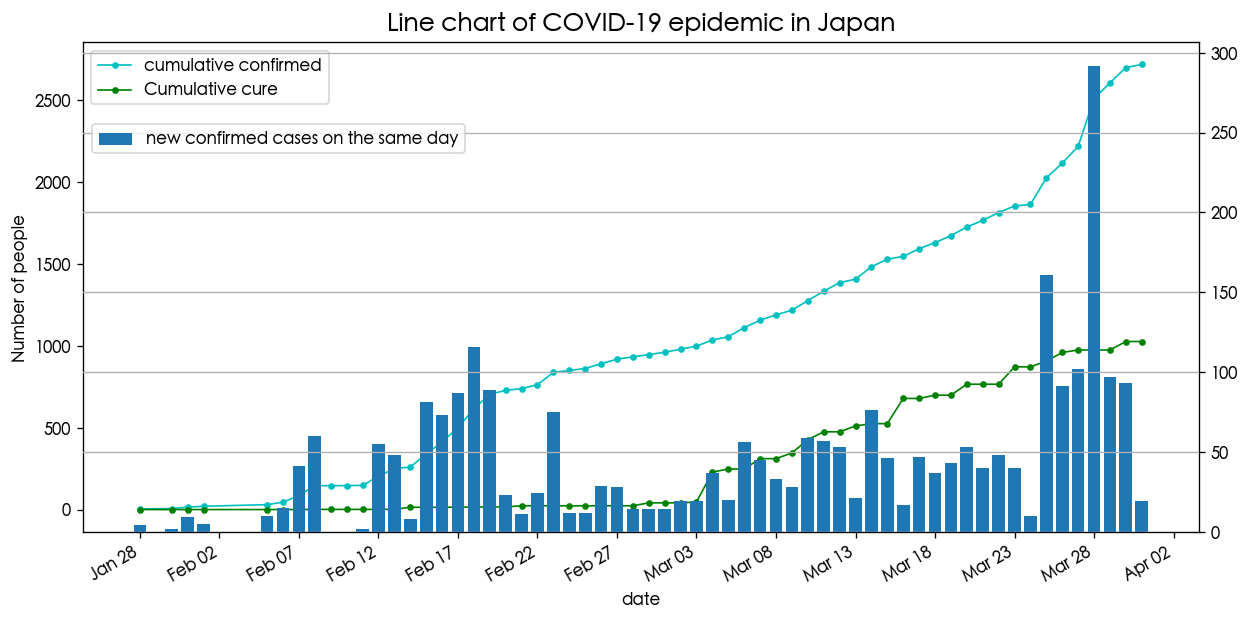

In [103]:
japan = alltime_world[alltime_world['name']=='日本']

fig, ax = plt.subplots(figsize=(12,6))

japan['cumulative confirmed'].plot(ax=ax, fontsize=10, style='-',lw=1,color='c',marker='o',ms=3,legend=True)
ax.set_ylabel('Number of people', fontsize=10)

japan['Cumulative cure'].plot(ax=ax, fontsize=10, style='-',lw=1,color='g',marker='o',ms=3,legend=True)
ax.set_ylabel('Number of people', fontsize=10)

ax1 = ax.twinx()
ax1.bar(japan.index, japan['new confirmed cases on the same day'])
ax1.xaxis.set_major_locator(dates.DayLocator(interval = 5))
ax1.xaxis.set_major_formatter(dates.DateFormatter('%b %d'))
ax1.legend(['new confirmed cases on the same day'],loc='upper left',bbox_to_anchor=(0.001, 0.85))
plt.grid(axis='y')
plt.box(False)
plt.title('Line chart of COVID-19 epidemic in Japan',size=15)

plt.show()

We found that the change in the number of new confirmed cases in Japan in the early stage did not increase much, but from March 25, the number of new confirmed cases in Japan increased significantly, and the cumulative slope of confirmed cases also increased.

# <a id=4></a>4. Summary

This case uses kaggle platform data to conduct exploratory analysis of COVID-19 epidemic data. Among them, data preprocessing mainly includes feature column renaming, missing value processing, viewing duplicate values, data type conversion and other operations. In addition, we also use Pandas for data visualisation and explore the connotation of data through chart drawing. At the same time, we introduced the processing method of time series data and the operation method of using Groupby technology for data grouping.